# MIB Crystal Analysis Quick Workflow

This notebook is a lightweight entry point for large MIB data. Keep reusable logic in `general_py4DSTEM_crystal_workflow.py` and the APP services; use this notebook for parameter selection, visual checks, and staged execution.

Default target: `DataCube (512, 512, 256, 256)`, about 32 GB. Always start with `MEMMAP` and a centered `128 x 128` ROI before full-dataset phase/orientation matching.


In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import py4DSTEM

MIB_FILE = Path(r"D:\Downloads\0617-4d\1_512x512_ss15.63nm_0.55ms_c2 50um_CL91mm_0.75mrad_spot7_0.022nA_GL3_mag12500k_12b 0913.mib")
SCAN_SHAPE = (512, 512)
MEM_MODE = 'MEMMAP'
ROI = (192, 320, 192, 320)  # rx0, rx1, ry0, ry1; 128 x 128 centered tuning ROI
OUTPUT_DIR = Path('mib_crystal_output')
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Import and Mean Diffraction Pattern

MIB input must use `scan=(512, 512)` and `mem='MEMMAP'` unless you intentionally override them.


Header file (.hdr) does not exist in this folder. The scan size will be assumed to be 512 by 512 pix


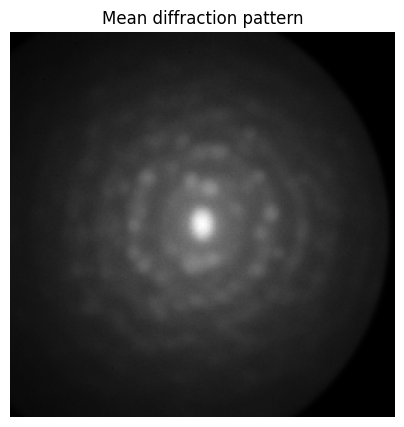

In [10]:
dc = py4DSTEM.import_file(str(MIB_FILE), mem=MEM_MODE, scan=SCAN_SHAPE)
mean_dp = dc.get_dp_mean().data

plt.figure(figsize=(5, 5))
plt.imshow(np.log1p(mean_dp), cmap='gray')
plt.title('Mean diffraction pattern')
plt.axis('off');


## 2. ROI-First Bragg Detection

Tune Bragg-disk parameters on the ROI. Only switch to full dataset after the BVM and confidence maps are stable.


get_vacuum_probe 失败，改用 ROI 平均 diffraction pattern 作为临时 template。
原始错误： TypeError("DataCube.get_vacuum_probe() got an unexpected keyword argument 'verbose'")
template shape: (256, 256) dtype: float32
template_binned shape: (128, 128)
dc_roi_small shape: (64, 64, 128, 128)


Finding Bragg Disks: 100%|██████████| 4.10k/4.10k [00:07<00:00, 536DP/s]  


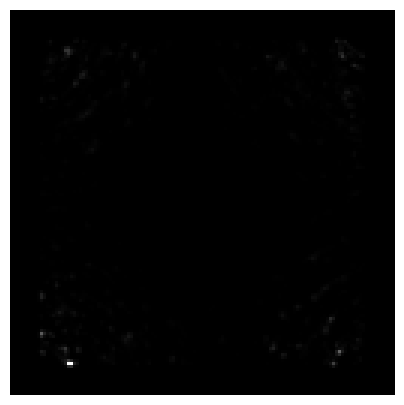

1625

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import py4DSTEM
import gc

rx0, rx1, ry0, ry1 = ROI

BIN_Q = 2
THIN_R = 2


def bin2d_mean(a, n=2):
    sx = (a.shape[0] // n) * n
    sy = (a.shape[1] // n) * n
    a = a[:sx, :sy]
    return a.reshape(sx // n, n, sy // n, n).mean(axis=(1, 3)).astype(np.float32)


def extract_2d_template_from_probe(probe_obj):
    """
    兼容不同 py4DSTEM 版本：
    probe 可能是 numpy array，也可能有 .kernel / .data 属性。
    """
    if hasattr(probe_obj, "kernel"):
        template = probe_obj.kernel
        if callable(template):
            template = template()
    elif hasattr(probe_obj, "data"):
        template = probe_obj.data
    else:
        template = probe_obj

    template = np.asarray(template, dtype=np.float32)

    if template.ndim != 2:
        raise ValueError(f"template 必须是 2D array，但现在 shape = {template.shape}")

    return template


# ============================================================
# 1. 生成 Bragg disk detection template
# ============================================================
# 最好使用 vacuum / amorphous / background 区域作为 probe template。
# 如果你还没有单独选 vacuum ROI，可以暂时用当前 ROI 生成，但不如真正 vacuum 区域理想。

try:
    probe = dc.get_vacuum_probe(
        ROI=ROI,
        align=True,
        verbose=True,
    )
    template = extract_2d_template_from_probe(probe)

except Exception as e:
    print("get_vacuum_probe 失败，改用 ROI 平均 diffraction pattern 作为临时 template。")
    print("原始错误：", repr(e))

    # 临时 fallback：用 ROI 内平均 diffraction pattern 作为 template
    # 这不是最理想的 Bragg template，但可以先让流程跑通。
    template = np.asarray(
        dc.data[rx0:rx1:THIN_R, ry0:ry1:THIN_R, :, :].mean(axis=(0, 1)),
        dtype=np.float32,
    )


print("template shape:", template.shape, "dtype:", template.dtype)


# ============================================================
# 2. 对 template 做 Q-space binning
# ============================================================
template_binned = bin2d_mean(template, BIN_Q)

print("template_binned shape:", template_binned.shape)


# ============================================================
# 3. 构建小 ROI DataCube
#    注意这里直接用 rx0:rx1:THIN_R, ry0:ry1:THIN_R，
#    避免先生成完整 ROI 后再 thin_R，能省很多内存。
# ============================================================
roi_data_small = np.asarray(
    dc.data[rx0:rx1:THIN_R, ry0:ry1:THIN_R, :, :],
    dtype=np.float32,
)

dc_roi_small = py4DSTEM.DataCube(
    roi_data_small,
    name="dc_roi_small",
    calibration=dc.calibration,
)

# Q-space binning
dc_roi_small = dc_roi_small.bin_Q(BIN_Q, dtype=np.float32)

print("dc_roi_small shape:", dc_roi_small.data.shape)


# ============================================================
# 4. Bragg disk detection
# ============================================================
bragg_peaks = dc_roi_small.find_Bragg_disks(
    template=template_binned,
    corrPower=1.0,
    sigma_cc=1,
    edgeBoundary=10,
    minRelativeIntensity=0.05,
    minPeakSpacing=4,
    subpixel="poly",
    maxNumPeaks=70,
    CUDA=False,
)

bvm = bragg_peaks.histogram(mode="cal")


# ============================================================
# 5. Plot Bragg vector map
# ============================================================
plt.figure(figsize=(5, 5))
plt.imshow(bvm.data, cmap="gray", origin="lower")
plt.axis("off")
plt.show()

gc.collect()

## 3. Crystal Analysis

Phase matching and orientation matching share the same calibrated `BraggVectors`. Add candidate CIF files, build one orientation library per phase, then assign the phase with the highest score at each scan point.


In [13]:
# Replace these with your actual CIF paths. v1 does not bundle a crystal database.
PHASES = {
    'Ti-bcc': Path(r"D:\Downloads\Ti-bcc.cif"),
    'Ti-hcp': Path(r"D:\Downloads\Ti-hcp.cif"),
}

crystals = {}
for phase_name, cif_path in PHASES.items():
    crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(str(cif_path))
    crystal.setup_diffraction(accelerating_voltage=300_000)
    crystal.calculate_structure_factors(k_max=1.5, tol_structure_factor=1e-4)
    crystal.orientation_plan(
        zone_axis_range='auto',
        angle_step_zone_axis=5,
        angle_step_in_plane=5,
        progress_bar=True,
    )
    crystals[phase_name] = crystal


get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().


Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 78/78 [00:00<00:00, 19771.30 zone axes/s]
get_structures is deprecated; use parse_structures in pymatgen.io.cif instead.
The only difference is that primitive defaults to False in the new parse_structures method.So parse_structures(primitive=True) is equivalent to the old behavior of get_structures().
Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.


Automatically detected point group 6/mmm,
 using arguments: zone_axis_range = 
[[0.8660254 0.5       0.       ]
 [1.        0.        0.       ]], 
 fiber_axis=None, fiber_angles=None.


Orientation plan: 100%|██████████| 190/190 [00:00<00:00, 17265.00 zone axes/s]


In [14]:
orientation_maps = {}
score_maps = []
phase_names = list(crystals)

for phase_name, crystal in crystals.items():
    omap = crystal.match_orientations(
        bragg_peaks,
        num_matches_return=1,
        min_angle_between_matches_deg=2,
        min_number_peaks=3,
        progress_bar=True,
    )
    orientation_maps[phase_name] = omap
    score = np.asarray(getattr(omap, 'corr', getattr(omap, 'corr_map', None)), dtype=float)
    score_maps.append(score[:, :, 0] if score.ndim >= 3 else score)

score_stack = np.stack(score_maps, axis=0)
phase_id_map = np.argmax(score_stack, axis=0)
best_score = np.max(score_stack, axis=0)
sorted_score = np.sort(score_stack, axis=0)
confidence_gap = sorted_score[-1] - sorted_score[-2] if len(score_maps) > 1 else np.ones_like(best_score)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(phase_id_map, cmap='tab10')
axes[0].set_title('Phase ID')
axes[1].imshow(best_score, cmap='viridis')
axes[1].set_title('Best score')
axes[2].imshow(confidence_gap, cmap='inferno')
axes[2].set_title('Confidence gap')
for ax in axes: ax.axis('off')


bragg peaks not rotationally calibrated
Matching Orientations:   0%|          | 0/4096 [00:00<?, ? PointList/s]


AssertionError: Requested calibration was not found!

## 4. Full Dataset

After ROI validation, repeat Bragg detection on `dc` instead of `dc_roi` and reuse the same CIF/orientation parameters. Grain and strain analysis are optional; if the installed py4DSTEM version lacks those APIs, keep phase/orientation results and record the warning.
